# T24 Dayside MMS Data Analysis

## Overview
This notebook analyzes the dayside-filtered MMS data labeled with T24 regions.

**Data Structure:**
- **Flux**: Ion energy flux timeseries (40 timesteps × 32 energy channels)
- **Parameters**: B-field, Temperature, X position (40 timesteps × 3 features)
- **Labels**: T24 region classifications (Solar Wind, Ion Foreshock, Magnetosheath, Magnetosphere)

**T24 Regions (Dayside):**
- **Solar Wind (SW)**: Region dominated by solar wind flow
- **Ion Foreshock (FS)**: Upstream region with backstreaming ions
- **Magnetosheath (MSH)**: Compressed solar wind between bow shock and magnetopause
- **Magnetosphere (MSP)**: Earth's magnetic field dominated region

## 1. Import Required Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch.utils.data import DataLoader
import h5py
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Load T24 Dayside Data

In [2]:
# Import utility module
from t24_dayside_utils import T24DaysideDataset

# Load dataset
dataset = T24DaysideDataset('dayside_t24_labeled.h5', normalize=True)

# Print statistics
dataset.print_statistics()


T24 DAYSIDE DATASET STATISTICS

File: dayside_t24_labeled.h5
Total samples: 344

Flux shape: torch.Size([344, 40, 32])
  Range: [0.000000, 1.000000]
  Mean: 0.017170, Std: 0.053637

Parameters shape: torch.Size([344, 40, 3])
  B (nT)    : [0.000000, 1.000000]
  T (eV)    : [0.000000, 1.000000]
  X (RE)    : [0.000000, 0.000000]

T24 Region Distribution:
  solar wind          :  101 ( 29.4%)
  ion foreshock       :  102 ( 29.7%)
  magnetosheath       :  101 ( 29.4%)
  magnetosphere       :   40 ( 11.6%)

Metadata:
  dayside_filter: X_GSE >= 0 (scaled coordinates)
  dayside_samples: 344
  mms_regions: sw,fs,msh,msp,ps,lobe
  source: MMS training data filtered to dayside
  t24_label_0: solar wind
  t24_label_1: ion foreshock
  t24_label_2: magnetosheath
  t24_label_3: magnetosphere
  total_samples: 592



## 3. Explore Region Characteristics

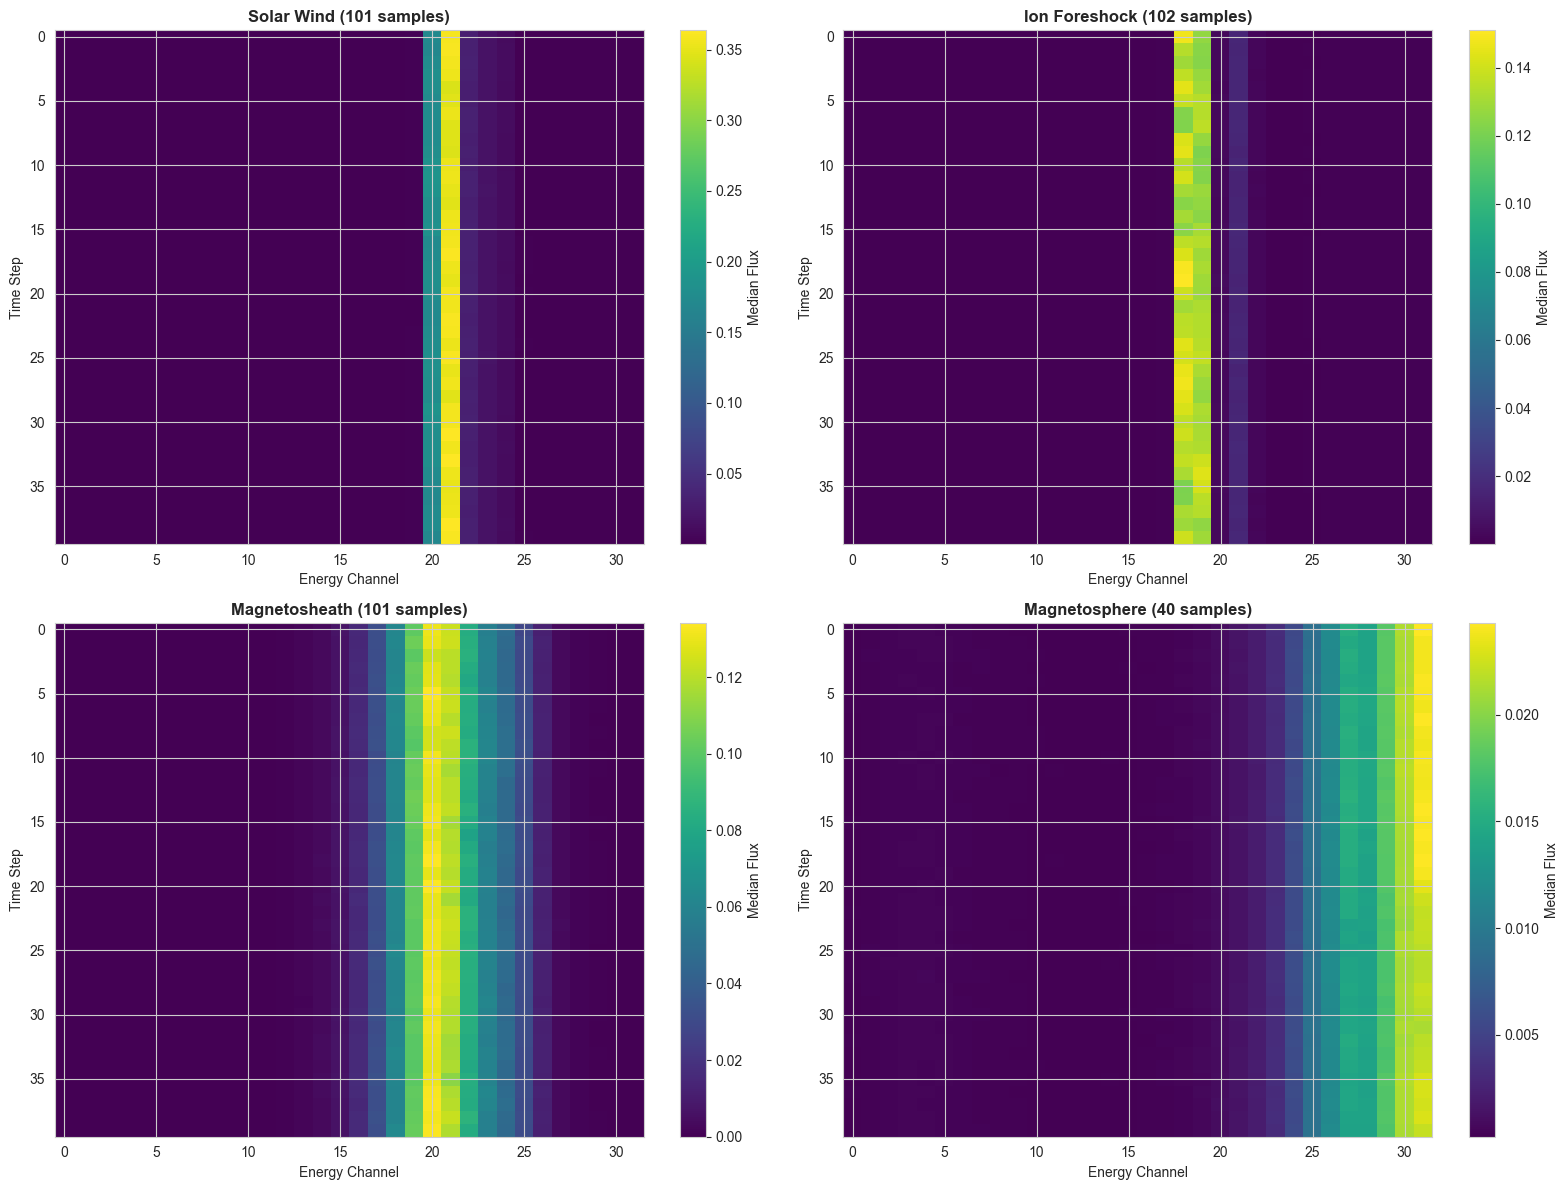


Region Statistics:

SOLAR WIND
  Samples: 101
  Flux range: [0.0000, 0.6240]
  Parameters shape: torch.Size([101, 40, 3])

ION FORESHOCK
  Samples: 102
  Flux range: [0.0000, 0.6532]
  Parameters shape: torch.Size([102, 40, 3])

MAGNETOSHEATH
  Samples: 101
  Flux range: [0.0000, 1.0000]
  Parameters shape: torch.Size([101, 40, 3])

MAGNETOSPHERE
  Samples: 40
  Flux range: [0.0000, 0.0308]
  Parameters shape: torch.Size([40, 40, 3])


In [3]:
# Get region information
regions = ['solar wind', 'ion foreshock', 'magnetosheath', 'magnetosphere']
region_info = {}

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, region in enumerate(regions):
    region_data = dataset.get_region_samples(region)
    region_info[region] = region_data
    
    # Plot median flux
    flux = region_data['flux']
    flux_median = flux.median(dim=0)[0]  # Median across all samples
    
    ax = axes[idx]
    im = ax.imshow(flux_median.numpy(), aspect='auto', cmap='viridis')
    ax.set_title(f'{region.title()} ({region_data["count"]} samples)', fontsize=12, fontweight='bold')
    ax.set_xlabel('Energy Channel')
    ax.set_ylabel('Time Step')
    plt.colorbar(im, ax=ax, label='Median Flux')

plt.tight_layout()
plt.savefig('region_median_flux.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nRegion Statistics:")
print("="*70)
for region in regions:
    data = region_info[region]
    print(f"\n{region.upper()}")
    print(f"  Samples: {data['count']}")
    print(f"  Flux range: [{data['flux'].min():.4f}, {data['flux'].max():.4f}]")
    print(f"  Parameters shape: {data['parameters'].shape}")

## 4. Parameter Analysis by Region

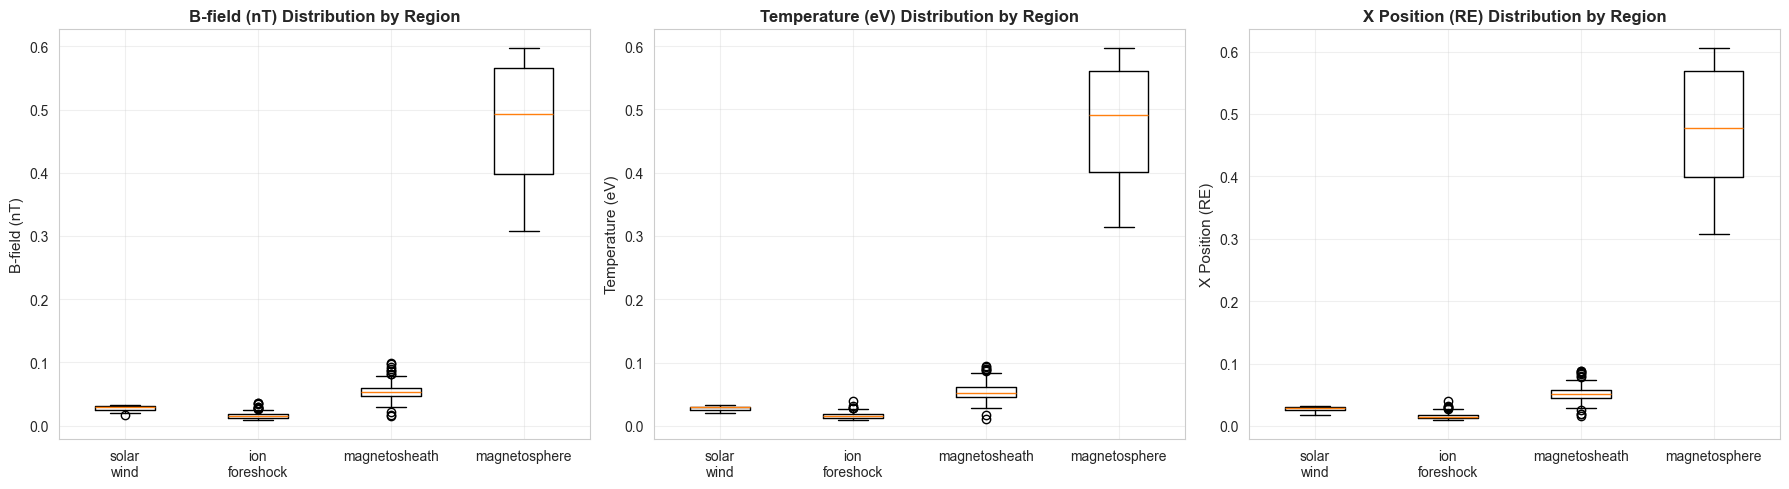

Parameter Statistics by Region

B-field (nT):
  solar wind          : mean=0.028, std=0.003
  ion foreshock       : mean=0.016, std=0.006
  magnetosheath       : mean=0.055, std=0.016
  magnetosphere       : mean=0.483, std=0.087

Temperature (eV):
  solar wind          : mean=0.028, std=0.003
  ion foreshock       : mean=0.016, std=0.005
  magnetosheath       : mean=0.055, std=0.015
  magnetosphere       : mean=0.483, std=0.084

X Position (RE):
  solar wind          : mean=0.028, std=0.003
  ion foreshock       : mean=0.016, std=0.006
  magnetosheath       : mean=0.053, std=0.014
  magnetosphere       : mean=0.483, std=0.086


In [4]:
# Analyze parameters (B, T, X) by region
param_names = ['B-field (nT)', 'Temperature (eV)', 'X Position (RE)']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for param_idx, (ax, param_name) in enumerate(zip(axes, param_names)):
    # Collect all parameter values for each region
    data_by_region = []
    labels_by_region = []
    
    for region in regions:
        params = region_info[region]['parameters']
        # Take mean across timesteps
        param_values = params[:, param_idx, :].mean(dim=1)  # (N_samples,)
        data_by_region.append(param_values.numpy())
        labels_by_region.extend([region.replace(' ', '\n')] * len(param_values))
    
    # Create box plot
    ax.boxplot(data_by_region, labels=[r.replace(' ', '\n') for r in regions])
    ax.set_ylabel(param_name, fontsize=11)
    ax.set_title(f'{param_name} Distribution by Region', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('region_parameter_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Print statistics
print("Parameter Statistics by Region")
print("="*70)
for param_idx, param_name in enumerate(param_names):
    print(f"\n{param_name}:")
    for region in regions:
        params = region_info[region]['parameters']
        param_values = params[:, param_idx, :].mean(dim=1)
        print(f"  {region:<20}: mean={param_values.mean():.3f}, std={param_values.std():.3f}")

## 5. Create Data Loaders

In [5]:
# Create train/test split
train_loader, test_loader, train_indices, test_indices = dataset.get_dataloaders(
    batch_size=32,
    test_ratio=0.2
)

print(f"\nDataset splits created:")
print(f"  Train batches: {len(train_loader)}")
print(f"  Test batches: {len(test_loader)}")
print(f"  Batch size: 32")

Created dataloaders:
  Train samples: 275 (79.9%)
  Test samples: 69 (20.1%)

Dataset splits created:
  Train batches: 9
  Test batches: 3
  Batch size: 32


## 6. Visualize Sample Data Points

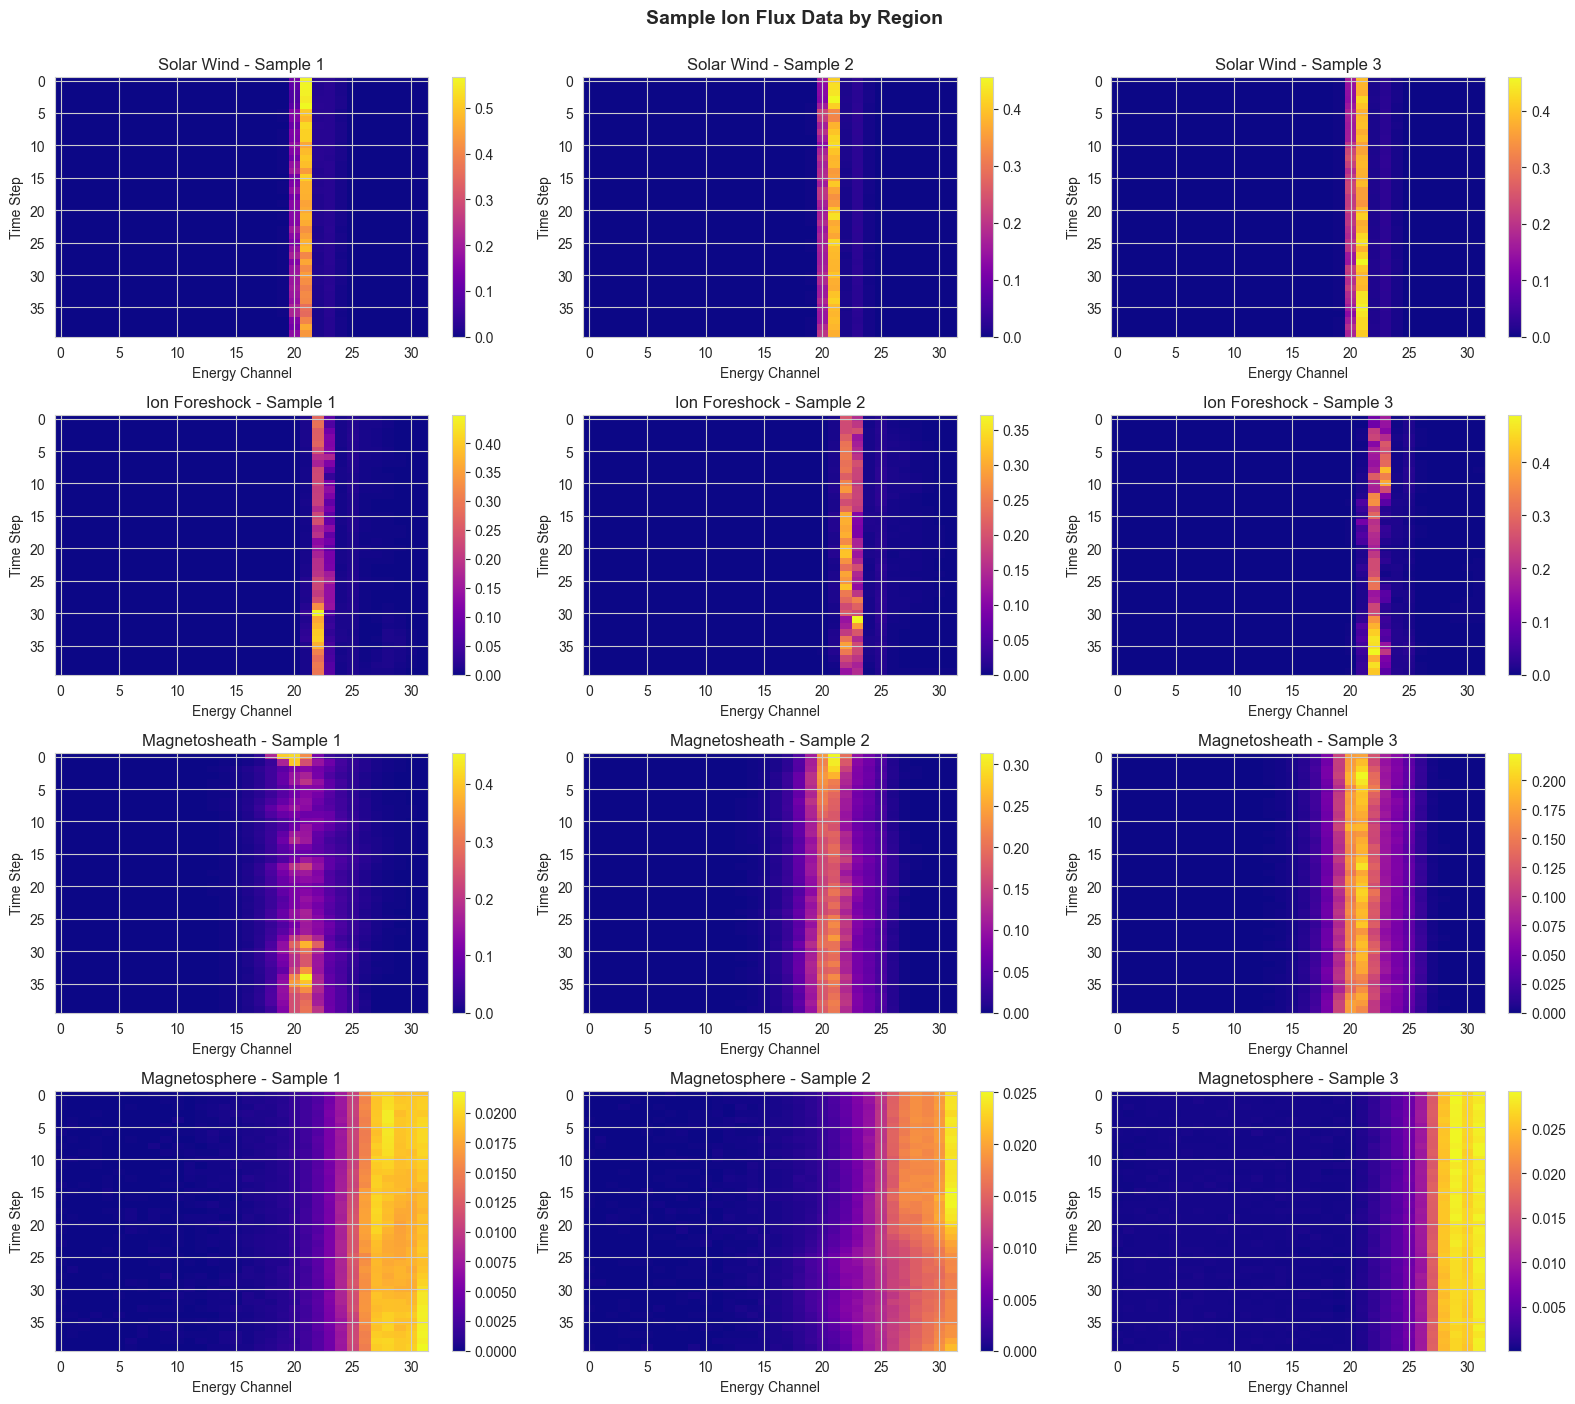

In [6]:
# Get one batch from each region
fig, axes = plt.subplots(4, 3, figsize=(16, 14))

for region_idx, region in enumerate(regions):
    # Get samples from this region
    region_data = dataset.get_region_samples(region)
    indices = region_data['indices'][:3]  # Get first 3 samples
    
    for sample_idx, sample_id in enumerate(indices):
        sample = dataset[int(sample_id)]
        flux = sample['flux'].squeeze().numpy()  # (40, 32)
        
        ax = axes[region_idx, sample_idx]
        im = ax.imshow(flux, aspect='auto', cmap='plasma')
        ax.set_title(f'{region.title()} - Sample {sample_idx+1}')
        ax.set_xlabel('Energy Channel')
        ax.set_ylabel('Time Step')
        plt.colorbar(im, ax=ax)

plt.suptitle('Sample Ion Flux Data by Region', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('sample_flux_data.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Label Distribution and Balance

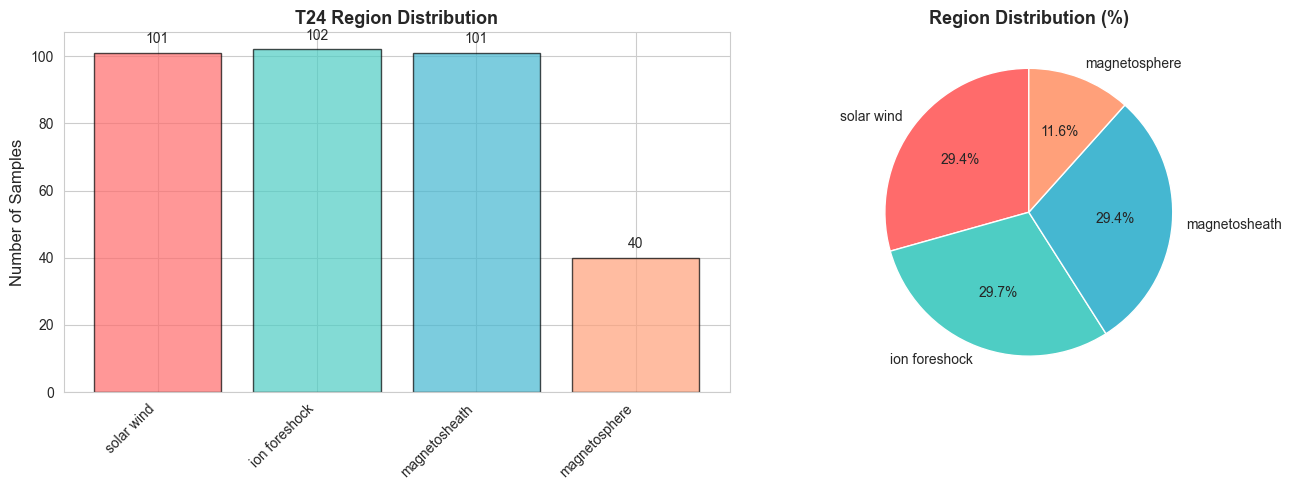


Label Distribution:
solar wind          :  101 ( 29.4%)
ion foreshock       :  102 ( 29.7%)
magnetosheath       :  101 ( 29.4%)
magnetosphere       :   40 ( 11.6%)


In [7]:
# Analyze class distribution
label_counts = np.bincount(dataset.labels_t24.numpy(), minlength=4)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']
ax1.bar(regions, label_counts, color=colors, alpha=0.7, edgecolor='black')
ax1.set_ylabel('Number of Samples', fontsize=12)
ax1.set_title('T24 Region Distribution', fontsize=13, fontweight='bold')
ax1.set_xticklabels(regions, rotation=45, ha='right')
for i, v in enumerate(label_counts):
    ax1.text(i, v + 2, str(v), ha='center', va='bottom')

# Pie chart
ax2.pie(label_counts, labels=regions, autopct='%1.1f%%', colors=colors, startangle=90)
ax2.set_title('Region Distribution (%)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nLabel Distribution:")
print("="*50)
for region, count in zip(regions, label_counts):
    pct = count / len(dataset) * 100
    print(f"{region:<20}: {count:4} ({pct:5.1f}%)")

## 8. Summary and Next Steps

In [8]:
summary = f"""
T24 DAYSIDE FILTERED DATASET - SUMMARY
{'='*70}

DATA CHARACTERISTICS:
  Total Samples (Dayside):  {len(dataset)}
  Flux Shape:              {dataset.flux.shape}
  Parameters Shape:        {dataset.parameters.shape}

REGION DISTRIBUTION:
  Solar Wind:              {label_counts[0]:4} ({label_counts[0]/len(dataset)*100:.1f}%)
  Ion Foreshock:           {label_counts[1]:4} ({label_counts[1]/len(dataset)*100:.1f}%)
  Magnetosheath:           {label_counts[2]:4} ({label_counts[2]/len(dataset)*100:.1f}%)
  Magnetosphere:           {label_counts[3]:4} ({label_counts[3]/len(dataset)*100:.1f}%)

DATA PREPARATION:
  Normalization:           Enabled (Min-Max scaling to [0,1])
  Train/Test Split:        80/20
  Train Samples:           {len(train_indices)}
  Test Samples:            {len(test_indices)}

NEXT STEPS:
  1. Load into your CNN+RF hybrid model for training
  2. Compare predictions with T24 labels for validation
  3. Consider retraining for dayside-specific improvements
  4. Analyze confusion matrices to identify misclassifications
  5. Evaluate model performance per region

USAGE EXAMPLE:
  from t24_dayside_utils import T24DaysideDataset
  dataset = T24DaysideDataset('dayside_t24_labeled.h5')
  train_loader, test_loader, _, _ = dataset.get_dataloaders(batch_size=32)
"""

print(summary)


T24 DAYSIDE FILTERED DATASET - SUMMARY

DATA CHARACTERISTICS:
  Total Samples (Dayside):  344
  Flux Shape:              torch.Size([344, 40, 32])
  Parameters Shape:        torch.Size([344, 40, 3])

REGION DISTRIBUTION:
  Solar Wind:               101 (29.4%)
  Ion Foreshock:            102 (29.7%)
  Magnetosheath:            101 (29.4%)
  Magnetosphere:             40 (11.6%)

DATA PREPARATION:
  Normalization:           Enabled (Min-Max scaling to [0,1])
  Train/Test Split:        80/20
  Train Samples:           275
  Test Samples:            69

NEXT STEPS:
  1. Load into your CNN+RF hybrid model for training
  2. Compare predictions with T24 labels for validation
  3. Consider retraining for dayside-specific improvements
  4. Analyze confusion matrices to identify misclassifications
  5. Evaluate model performance per region

USAGE EXAMPLE:
  from t24_dayside_utils import T24DaysideDataset
  dataset = T24DaysideDataset('dayside_t24_labeled.h5')
  train_loader, test_loader, _, _ 

In [11]:
# Demo: Generate random predictions (baseline for comparison)
np.random.seed(42)
y_pred_random = np.random.randint(0, 4, size=len(comp.y_true_t24))

# Evaluate random predictions
metrics_random = comp.evaluate_predictions(y_pred_random)

print("BASELINE (RANDOM PREDICTIONS)")
print("="*70)
print(f"Overall Accuracy: {metrics_random['overall_accuracy']:.4f}")
print(f"Precision:        {metrics_random['precision']:.4f}")
print(f"Recall:           {metrics_random['recall']:.4f}")
print(f"F1-Score:         {metrics_random['f1']:.4f}")

print("\nPer-Class Performance:")
for region, scores in metrics_random['per_class_metrics'].items():
    print(f"\n{region.upper()}:")
    print(f"  Samples:   {scores['samples']}")
    print(f"  Accuracy:  {scores['accuracy']:.4f}")
    print(f"  Precision: {scores['precision']:.4f}")
    print(f"  Recall:    {scores['recall']:.4f}")


BASELINE (RANDOM PREDICTIONS)
Overall Accuracy: 0.2616
Precision:        0.2891
Recall:           0.2616
F1-Score:         0.2682

Per-Class Performance:

SOLAR WIND:
  Samples:   101
  Accuracy:  0.1980
  Precision: 1.0000
  Recall:    0.1980

ION FORESHOCK:
  Samples:   102
  Accuracy:  0.2647
  Precision: 1.0000
  Recall:    0.2647

MAGNETOSHEATH:
  Samples:   101
  Accuracy:  0.2970
  Precision: 1.0000
  Recall:    0.2970

MAGNETOSPHERE:
  Samples:   40
  Accuracy:  0.3250
  Precision: 1.0000
  Recall:    0.3250


### 9.5 How to Use with Your Trained CNN+RF Model

In [14]:
# Compare baseline (random) vs upper bound (perfect)
comparison_df = pd.DataFrame({
    'Metric': ['Overall Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Random (Baseline)': [
        metrics_random['overall_accuracy'],
        metrics_random['precision'],
        metrics_random['recall'],
        metrics_random['f1']
    ],
    'Perfect (Upper Bound)': [
        metrics_perfect['overall_accuracy'],
        metrics_perfect['precision'],
        metrics_perfect['recall'],
        metrics_perfect['f1']
    ]
})

# Add "Your Model" column (to be filled in with actual model predictions)
comparison_df['Your Model'] = '(Run with predictions)'

print("\nBENCHMARK COMPARISON")
print("="*80)
print(comparison_df.to_string(index=False))

print("\n\nINTERPRETATION:")
print("  • Random (Baseline):    Worst-case scenario for a random classifier")
print("  • Perfect (Upper Bound): Best-case scenario (100% accuracy)")
print("  • Your Model:           Should fall between these two benchmarks")
print("\n  Goal: Achieve accuracy > 70% (well above random baseline)")
print("  Target: Get close to perfect performance (>90% if possible)")



BENCHMARK COMPARISON
          Metric  Random (Baseline)  Perfect (Upper Bound)             Your Model
Overall Accuracy           0.261628                    1.0 (Run with predictions)
       Precision           0.289129                    1.0 (Run with predictions)
          Recall           0.261628                    1.0 (Run with predictions)
        F1-Score           0.268241                    1.0 (Run with predictions)


INTERPRETATION:
  • Random (Baseline):    Worst-case scenario for a random classifier
  • Perfect (Upper Bound): Best-case scenario (100% accuracy)
  • Your Model:           Should fall between these two benchmarks

  Goal: Achieve accuracy > 70% (well above random baseline)
  Target: Get close to perfect performance (>90% if possible)


### 9.7 Benchmark Comparison Table

In [15]:
# Generate detailed evaluation report for random predictions (baseline)
print("\n" + comp.generate_report(y_pred_random))

# Save results to JSON for later analysis
comp.save_results(y_pred_random, 'baseline_random_predictions.json')
print("✓ Evaluation results saved to: baseline_random_predictions.json")




T24 MODEL EVALUATION REPORT

OVERALL PERFORMANCE:
  Accuracy:    0.2616
  Precision:   0.2891
  Recall:      0.2616
  F1-Score:    0.2682

PER-CLASS PERFORMANCE:
────────────────────────────────────────────────────────────────────────────────

  SOLAR WIND:
    Samples:     101
    Accuracy:    0.1980
    Precision:   1.0000
    Recall:      0.1980

  ION FORESHOCK:
    Samples:     102
    Accuracy:    0.2647
    Precision:   1.0000
    Recall:      0.2647

  MAGNETOSHEATH:
    Samples:     101
    Accuracy:    0.2970
    Precision:   1.0000
    Recall:      0.2970

  MAGNETOSPHERE:
    Samples:     40
    Accuracy:    0.3250
    Precision:   1.0000
    Recall:      0.3250

CONFUSION MATRIX:
[[20 27 24 30]
 [23 27 24 28]
 [32 15 30 24]
 [ 7  9 11 13]]


Results saved to: baseline_random_predictions.json
✓ Evaluation results saved to: baseline_random_predictions.json


### 9.6 Generate Full Evaluation Report

In [16]:
# Example code template for your trained CNN+RF model
example_code = '''
# Step 1: Load your trained CNN+RF model
from model_builder import MultiInputModel
import torch

model = MultiInputModel()
model.load_state_dict(torch.load("path/to/your/model.pth"))
model.eval()

# Step 2: Get predictions on test set
X1_test_tensor = torch.from_numpy(dataset.flux[test_indices]).unsqueeze(1).float()
X2_test_tensor = torch.from_numpy(dataset.parameters[test_indices]).permute(0, 2, 1).float()

with torch.no_grad():
    model_output = model(X1_test_tensor, X2_test_tensor)
    y_pred = torch.argmax(model_output, dim=1).numpy()  # Shape: (69,)

# Step 3: Evaluate against T24 labels
comp = T24ModelComparison('dayside_t24_labeled.h5')
metrics = comp.evaluate_predictions(y_pred)

# Step 4: Generate visualizations and report
print(comp.generate_report(y_pred))
comp.plot_confusion_matrix(y_pred)
comp.plot_metrics_comparison(y_pred)
comp.save_results(y_pred, 'model_evaluation_results.json')
'''

print("INTEGRATION WITH YOUR CNN+RF MODEL")
print("="*70)
print(example_code)


INTEGRATION WITH YOUR CNN+RF MODEL

# Step 1: Load your trained CNN+RF model
from model_builder import MultiInputModel
import torch

model = MultiInputModel()
model.load_state_dict(torch.load("path/to/your/model.pth"))
model.eval()

# Step 2: Get predictions on test set
X1_test_tensor = torch.from_numpy(dataset.flux[test_indices]).unsqueeze(1).float()
X2_test_tensor = torch.from_numpy(dataset.parameters[test_indices]).permute(0, 2, 1).float()

with torch.no_grad():
    model_output = model(X1_test_tensor, X2_test_tensor)
    y_pred = torch.argmax(model_output, dim=1).numpy()  # Shape: (69,)

# Step 3: Evaluate against T24 labels
comp = T24ModelComparison('dayside_t24_labeled.h5')
metrics = comp.evaluate_predictions(y_pred)

# Step 4: Generate visualizations and report
print(comp.generate_report(y_pred))
comp.plot_confusion_matrix(y_pred)
comp.plot_metrics_comparison(y_pred)
comp.save_results(y_pred, 'model_evaluation_results.json')



In [13]:
# Perfect predictions (upper bound) - use true labels
y_pred_perfect = comp.y_true_t24.copy()

metrics_perfect = comp.evaluate_predictions(y_pred_perfect)

print("\nUPPER BOUND (PERFECT PREDICTIONS)")
print("="*70)
print(f"Overall Accuracy: {metrics_perfect['overall_accuracy']:.4f}")
print(f"Precision:        {metrics_perfect['precision']:.4f}")
print(f"Recall:           {metrics_perfect['recall']:.4f}")
print(f"F1-Score:         {metrics_perfect['f1']:.4f}")



UPPER BOUND (PERFECT PREDICTIONS)
Overall Accuracy: 1.0000
Precision:        1.0000
Recall:           1.0000
F1-Score:         1.0000


### 9.4 Perfect Predictions (Upper Bound for Comparison)

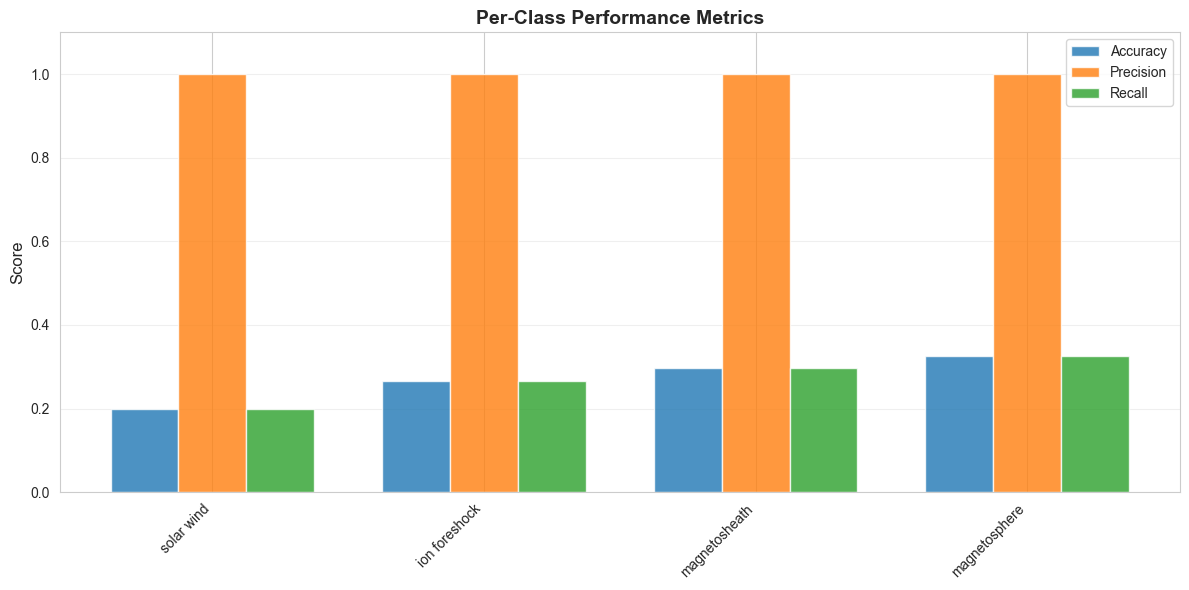

In [17]:
# Plot metrics for random predictions
comp.plot_metrics_comparison(y_pred_random, save_path='metrics_random.png')


### 9.3 Per-Class Metrics Comparison - Random vs Ideal

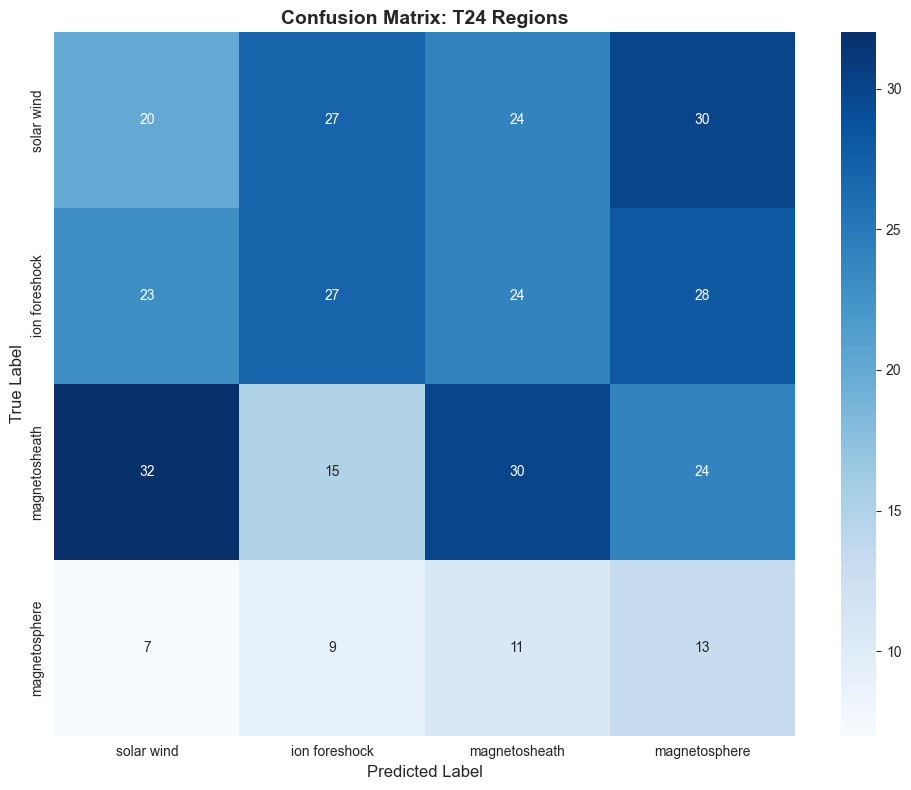

array([[20, 27, 24, 30],
       [23, 27, 24, 28],
       [32, 15, 30, 24],
       [ 7,  9, 11, 13]])

In [18]:
# Plot confusion matrix for random predictions
comp.plot_confusion_matrix(y_pred_random, save_path='confusion_matrix_random.png')


### 9.2 Confusion Matrix - Baseline Random Predictions

### 9.1 Demo: Evaluate with Random Predictions (Baseline)

In [10]:
from t24_model_comparison import T24ModelComparison

# Initialize comparison tool
comp = T24ModelComparison('dayside_t24_labeled.h5')

print(f"T24 Comparison Tool Initialized")
print(f"Total samples available: {len(comp.y_true_t24)}")
print(f"\nT24 Regions: {list(comp.T24_REGIONS.values())}")


T24 Comparison Tool Initialized
Total samples available: 344

T24 Regions: ['solar wind', 'ion foreshock', 'magnetosheath', 'magnetosphere']


## 9. Model Comparison & Validation with T24 Labels